# Regression and Classification on the Pima Indians Diabetes Dataset

 # Step 1 Project Overview

This project demonstrates a complete end-to-end supervised machine learning workflow using a healthcare dataset.

The project covers two different machine learning tasks:

### 1. Regression

The regression model predicts a patient's **BMI (Body Mass Index)** using clinical and demographic features such as:

- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- Diabetes Pedigree Function
- Age

The regression model is evaluated using **MAE, MSE, RMSE, and R²**.

### 2. Classification

The classification model predicts whether a patient has diabetes using relevant clinical and demographic features.

The classification model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

The project also includes data preprocessing, exploratory data analysis, train-test splitting, feature scaling, model training, predictions, evaluation, visualizations, and final conclusions.

##Step 2  Import Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## Step 3  Load Dataset

In [3]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## Step 4  Initial Dataset Inspection

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df.duplicated().sum()

np.int64(0)

##Step 5  Identify Invalid Values



This is an important part of the project.

Some medical measurements contain 0, although zero is physiologically implausible for variables such as:

Glucose BloodPressure SkinThickness Insulin BMI

We should therefore treat those zeros as missing values rather than real measurements. This is also noted in dataset documentation.

In [10]:
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in invalid_zero_columns:
    print(column, (df[column] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


## Step 6  Convert Invalid Zeros to NaN

### Why use NaN instead of directly replacing with mean?

Because zero doesn't mean the actual measurement is zero. We first represent it correctly as missing data, then impute it.

For this diabetes dataset, a good preprocessing approach is median imputation, because medical measurements can contain outliers

In [11]:
df_clean = df.copy()

df_clean[invalid_zero_columns] = (
    df_clean[invalid_zero_columns]
    .replace(0, np.nan)
)

In [12]:
df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Step 7  Exploratory Data Analysis

### Distribution

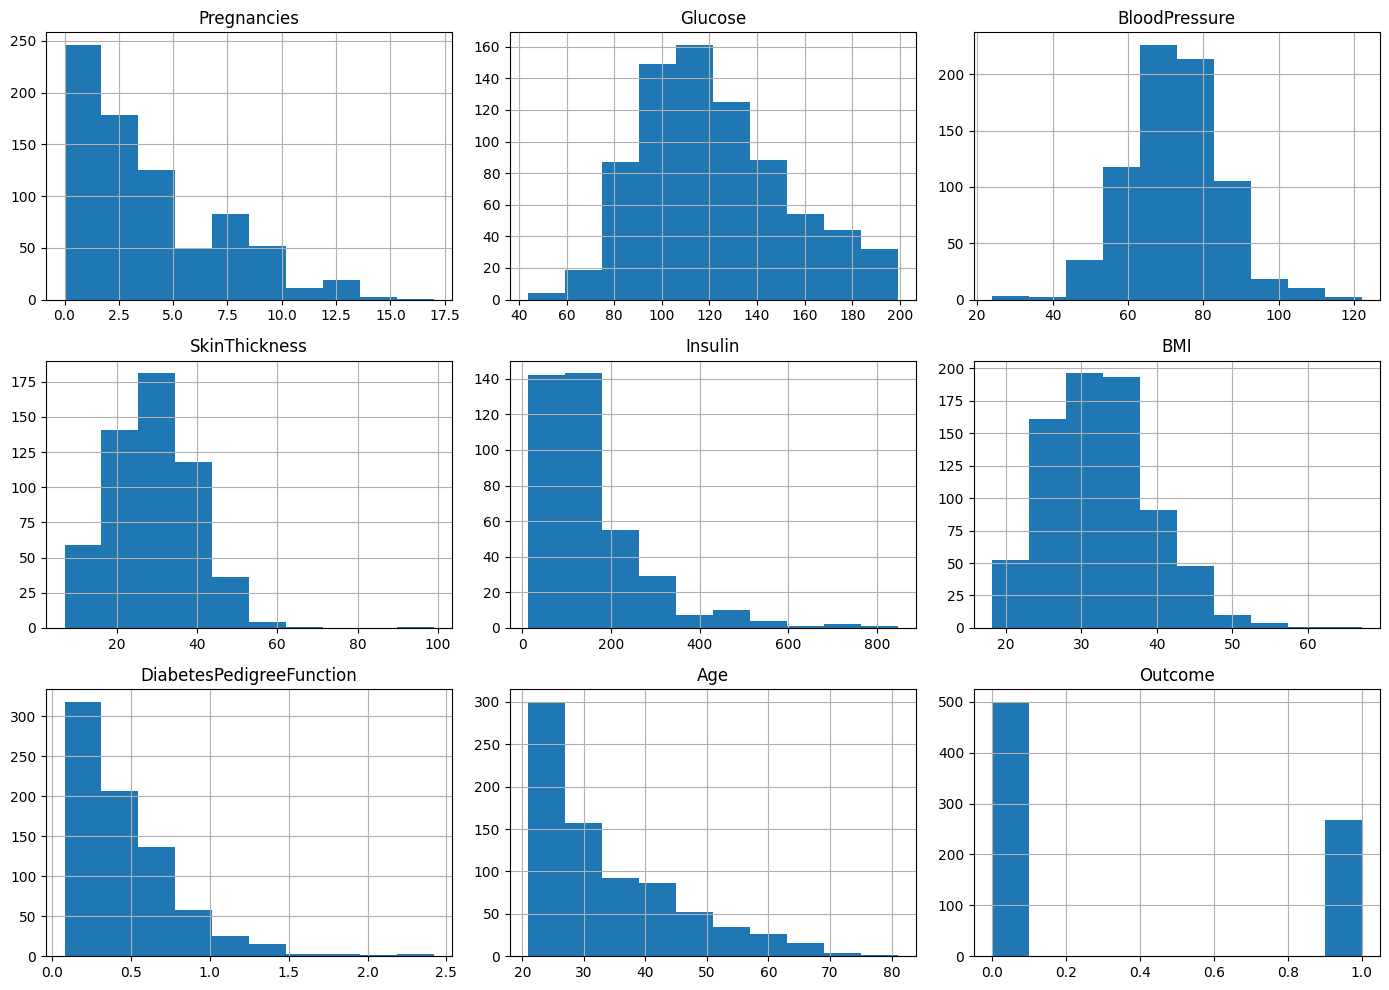

In [13]:
df_clean.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

### Correlation

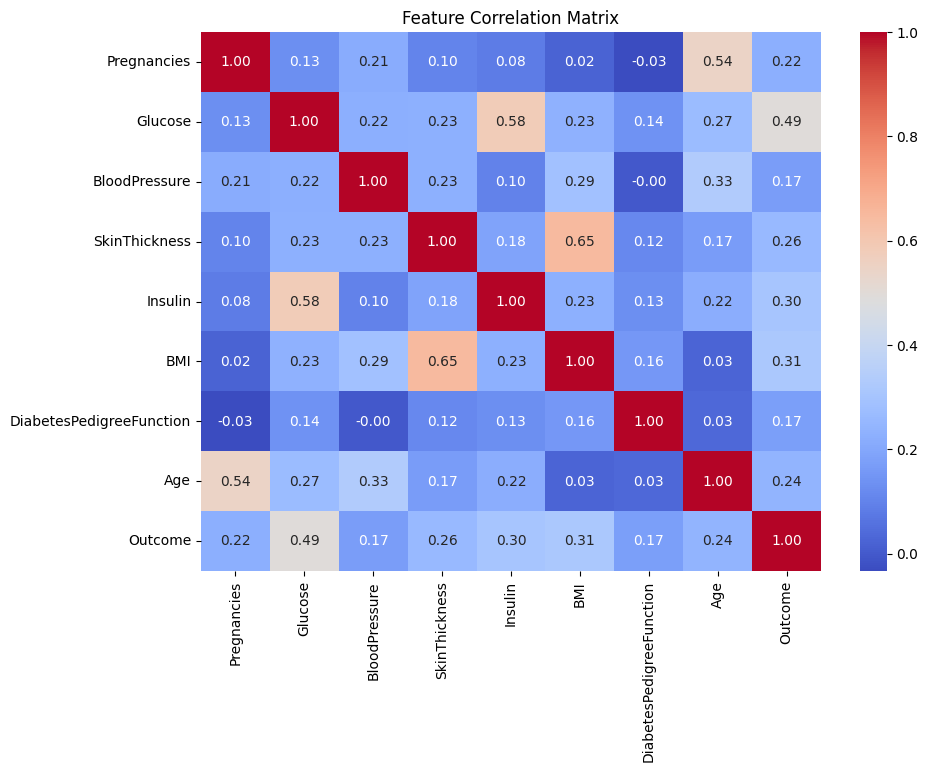

In [14]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

### Classification target distribution

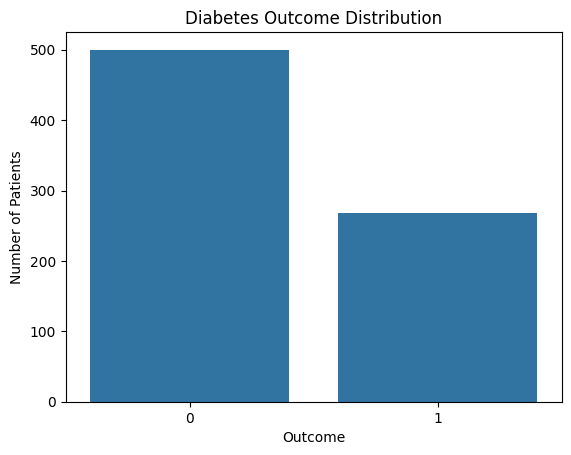

In [15]:
sns.countplot(data=df_clean, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

# Part A  Regression

## Step 8  Define Regression Features and Target



In this regression task, our goal is to predict the **BMI (Body Mass Index)** of a patient using other health-related features.

### Target Variable

Our target variable is:

**BMI**

### Features

We will use the following features to predict BMI:

- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- DiabetesPedigreeFunction
- Age

### X and y

- **X (Features):** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, DiabetesPedigreeFunction, Age
- **y (Target):** BMI

The regression model will learn the relationship between these health-related features and the patient's BMI.

In [16]:
regression_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "DiabetesPedigreeFunction",
    "Age"
]

X_reg = df_clean[regression_features]
y_reg = df_clean["BMI"]

##Step 9  Handle Missing Values

In [17]:
X_reg = X_reg.fillna(X_reg.median())
y_reg = y_reg.fillna(y_reg.median())

## Step 10  Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [19]:
print("Training features:", X_train_reg.shape)
print("Testing features:", X_test_reg.shape)

print("Training target:", y_train_reg.shape)
print("Testing target:", y_test_reg.shape)

Training features: (614, 7)
Testing features: (154, 7)
Training target: (614,)
Testing target: (154,)


## Step 11  Feature Scaling


Linear Regression does not strictly require feature scaling. However, we will apply standardization to make the preprocessing workflow consistent and to ensure that all features are placed on a similar scale.

We will use StandardScaler to standardize the features.

The scaler will be fitted only on the training data and then used to transform both the training and testing data. This prevents data leakage.

After scaling:

- Training features will have approximately a mean of 0.
- Training features will have approximately a standard deviation of 1.
- The same transformation will be applied to the test data.

In [20]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

The test data uses transform() instead of fit_transform().

This ensures that the test data is scaled using the parameters learned from the training data only.

This prevents data leakage and keeps the evaluation process fair and reliable.

## Step 12  Train Regression Model

In [21]:
regression_model = LinearRegression()

regression_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

LinearRegression()

## Step 13 Make Regression Predictions

In [22]:
y_pred_reg = regression_model.predict(X_test_reg_scaled)

y_pred_reg[:10]

array([31.13832868, 34.24670702, 31.67491763, 33.3239481 , 32.79992311,
       31.14397106, 24.16489507, 32.03603466, 32.76331153, 30.51021187])

In [23]:
comparison_reg = pd.DataFrame({
    "Actual BMI": y_test_reg.values,
    "Predicted BMI": y_pred_reg
})

comparison_reg.head(10)

,Actual BMI,Predicted BMI
0,34.0,31.138329
1,35.7,34.246707
2,30.8,31.674918
3,24.6,33.323948
4,29.9,32.799923
5,37.7,31.143971
6,20.4,24.164895
7,33.8,32.036035
8,31.3,32.763312
9,33.7,30.510212


## Step 14  Evaluate Regression

We should use multiple regression metrics.

### MAE  Mean Absolute Error

MAE measures the average absolute difference between the actual values and the predicted values.

It tells us how far the model's predictions are from the actual values on average.

### Formula

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

Where:

- $n$ = total number of observations
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $|y_i - \hat{y}_i|$ = absolute prediction error

### Numerical Example

Suppose the actual BMI values are:

```text
Actual:     25    30    35    40

In [24]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)

### MSE  Mean Squared Error

MSE measures the average of the squared differences between the actual values and the predicted values.

Because the errors are squared, **larger errors receive more penalty**.

A **lower MSE indicates better model performance**.

### Formula

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Where:

- $n$ = total number of observations
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $(y_i - \hat{y}_i)^2$ = squared prediction error

### Numerical Example

Suppose the actual BMI values are:

```text
Actual:     25    30    35    40

In [25]:
mse = mean_squared_error(y_test_reg, y_pred_reg)

### RMSE  Root Mean Squared Error

RMSE is the square root of the Mean Squared Error (MSE).

It measures the typical size of prediction errors and is expressed in the **same unit as the target variable**.

A **lower RMSE indicates better model performance**.

### Formula

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

Where:

- $n$ = total number of observations
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $(y_i - \hat{y}_i)^2$ = squared prediction error

### Numerical Example

Using the same example:

```text
Actual:     25    30    35    40
Predicted:  27    28    32    43

In [26]:
rmse = np.sqrt(mse)

### R²  R-Squared

R², also called the **Coefficient of Determination**, measures how well the regression model explains the variation in the target variable.

The value of R² is usually between **0 and 1**:

- **R² = 1:** The model explains 100% of the variation.
- **R² = 0:** The model explains none of the variation.
- **Higher R²:** Generally indicates a better fit.
- **Lower R²:** Indicates that the model explains less of the variation.

### Formula

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

Where:

- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $\bar{y}$ = mean of the actual values
- $n$ = total number of observations

### Numerical Example

Suppose the actual BMI values are:

```text
Actual:     25    30    35    40

In [27]:
r2 = r2_score(y_test_reg, y_pred_reg)

In [28]:
print("Regression Results")
print("-" * 30)
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Regression Results
------------------------------
MAE  : 4.387
MSE  : 34.788
RMSE : 5.898
R²   : 0.205


### Interpretation

- **MAE:** Shows the average absolute difference between the actual and predicted BMI values. It is measured in BMI units.
- **MSE:** Gives more importance to larger prediction errors because the errors are squared.
- **RMSE:** Shows the typical prediction error in the original BMI unit, making it easier to interpret than MSE.
- **R²:** Shows how much of the variation in BMI is explained by the regression model.

For this task, **MAE and RMSE are particularly useful** because they directly tell us how far the predictions are from the actual BMI values. **R²** helps us understand how well the model explains the overall variation in BMI.

## Step 15  Regression Visualization

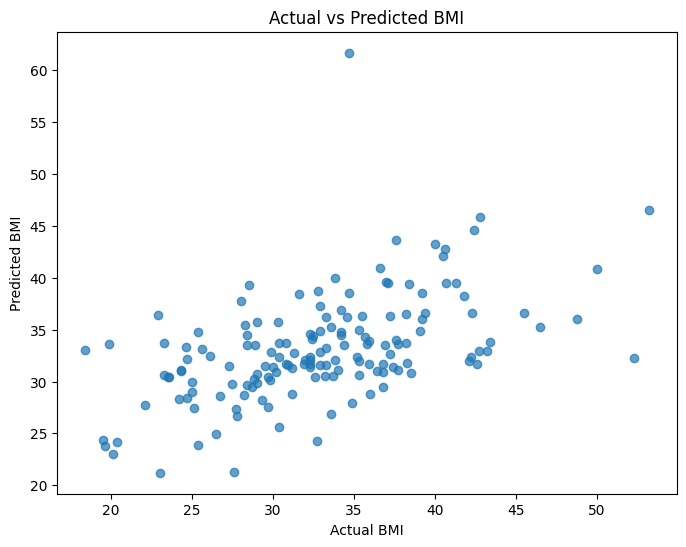

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_reg, y_pred_reg, alpha=0.7)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")

plt.show()

# Part B  Classification

# Step 16 Define Classification Features



In this classification task, our goal is to predict whether a patient has diabetes based on the available health-related features.

### Target Variable

The target variable is:

**Outcome**

- `0`  No diabetes
- `1`  Diabetes

### Features

We will use the available patient health features as input variables.

We will **exclude BMI** from the classification features because BMI was already used as the target variable in our regression task.

This keeps the two tasks separate and avoids using the regression target directly as an input feature for classification.

In [30]:
classification_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "DiabetesPedigreeFunction",
    "Age"
]

X_cls = df_clean[classification_features]
y_cls = df_clean["Outcome"]

## Step 17  Handle Missing Values

In [31]:
X_cls = X_cls.fillna(X_cls.median())

## Step 18  Train/Test Split

For classification, use stratification because the target classes may not be perfectly balanced.

In [32]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

This is better than simply using a random split because it preserves approximately the same class distribution in training and testing sets.

## Step 19 Feature Scaling



Feature scaling is the process of transforming numerical features so that they have a similar scale.

In classification, scaling is especially useful for algorithms such as **Logistic Regression**, because features with larger numerical ranges can have a greater influence during model optimization.

We will use StandardScaler to standardize the features.

### Standardization Formula

$$
z = \frac{x-\mu}{\sigma}
$$

Where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature
- $z$ = standardized value

After standardization, the training features will have approximately:

- **Mean = 0**
- **Standard deviation = 1**

### Important: Avoid Data Leakage

The scaler must be fitted **only on the training data**.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_cls)
X_test_scaled = scaler.transform(X_test_cls)

In [33]:
scaler_cls = StandardScaler()

X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

## Step 20  Train Logistic Regression

In [34]:
classification_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

classification_model.fit(
    X_train_cls_scaled,
    y_train_cls
)

LogisticRegression(max_iter=1000, random_state=42)

## Step 21  Make Class Predictions

In [35]:
y_pred_cls = classification_model.predict(X_test_cls_scaled)

In [36]:
y_pred_cls[:20]

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0])

## Step 22  Get Prediction Probabilities

This is important because classification models can produce both classes and probabilities.

In [37]:
y_prob_cls = classification_model.predict_proba(
    X_test_cls_scaled
)[:, 1]

## Step 23 Classification Evaluation

### Accuracy

Accuracy measures the proportion of correctly classified predictions out of all predictions made by the classification model.

### Formula

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Where:

- **TP (True Positive):** Diabetic patient correctly classified as diabetic.
- **TN (True Negative):** Non-diabetic patient correctly classified as non-diabetic.
- **FP (False Positive):** Non-diabetic patient incorrectly classified as diabetic.
- **FN (False Negative):** Diabetic patient incorrectly classified as non-diabetic.

### Numerical Example

Suppose our classification model produces the following results:

```text
TP = 40
TN = 50
FP = 5
FN = 5

In [38]:
accuracy = accuracy_score(
    y_test_cls,
    y_pred_cls
)

### Precision

Precision measures how many of the patients predicted as **diabetic** by the model are actually diabetic.

In other words, precision tells us how reliable the model's positive predictions are.

### Formula

$$
Precision = \frac{TP}{TP + FP}
$$

Where:

- **TP (True Positive):** Diabetic patient correctly classified as diabetic.
- **FP (False Positive):** Non-diabetic patient incorrectly classified as diabetic.

### Numerical Example

Suppose our classification model produces:

```text
TP = 40
FP = 5

In [39]:
precision = precision_score(
    y_test_cls,
    y_pred_cls
)

### Recall

Recall measures how many of the patients who are **actually diabetic** are correctly identified by the model.

It is also called **Sensitivity** or **True Positive Rate (TPR)**.

### Formula

$$
Recall = \frac{TP}{TP + FN}
$$

Where:

- **TP (True Positive):** Diabetic patient correctly classified as diabetic.
- **FN (False Negative):** Diabetic patient incorrectly classified as non-diabetic.

### Numerical Example

Suppose our classification model produces:

```text
TP = 40
FN = 10

In [40]:
recall = recall_score(
    y_test_cls,
    y_pred_cls
)

### F1 Score

F1 Score is the harmonic mean of **Precision** and **Recall**.

It provides a single metric that balances both:

- **Precision:** How reliable the positive predictions are.
- **Recall:** How many actual positive cases the model correctly identifies.

### Formula

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

### Numerical Example

Suppose our model has:

```text
Precision = 0.889
Recall    = 0.800

In [41]:
f1 = f1_score(
    y_test_cls,
    y_pred_cls
)

### ROC-AUC

ROC-AUC is a classification metric that measures how well the model can distinguish between the two classes.

- **ROC** stands for **Receiver Operating Characteristic**.
- **AUC** stands for **Area Under the Curve**.

The ROC curve plots:

- **True Positive Rate (TPR)** against
- **False Positive Rate (FPR)**

at different classification thresholds.

### Formulas

True Positive Rate:

$$
TPR = \frac{TP}{TP + FN}
$$

False Positive Rate:

$$
FPR = \frac{FP}{FP + TN}
$$

### What Does AUC Mean?

The AUC value ranges from **0 to 1**:

| AUC | Interpretation |
|---:|---|
| 1.0 | Perfect classification |
| 0.9–1.0 | Excellent |
| 0.8–0.9 | Good |
| 0.7–0.8 | Acceptable |
| 0.5–0.7 | Weak |
| 0.5 | Random guessing |
| < 0.5 | Worse than random |

### Numerical Example

Suppose our model produces:

```text
ROC-AUC = 0.85

In [42]:
roc_auc = roc_auc_score(
    y_test_cls,
    y_prob_cls
)

In [43]:
print("Classification Results")
print("-" * 30)
print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")
print(f"ROC-AUC   : {roc_auc:.3f}")

Classification Results
------------------------------
Accuracy  : 0.708
Precision : 0.600
Recall    : 0.500
F1 Score  : 0.545
ROC-AUC   : 0.803


## Step 24  Classification Report

In [44]:
print(
    classification_report(
        y_test_cls,
        y_pred_cls
    )
)

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## Step 25  Confusion Matrix

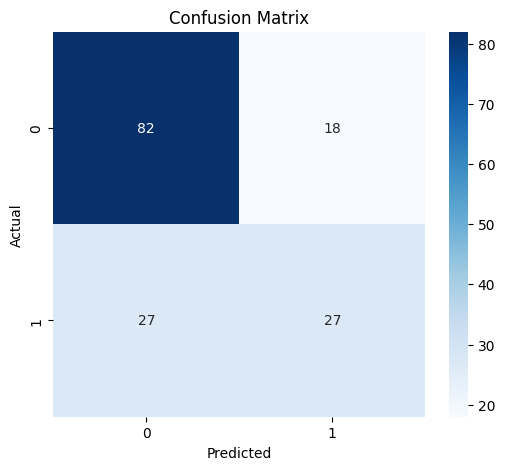

In [45]:
cm = confusion_matrix(
    y_test_cls,
    y_pred_cls
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Confusion Matrix Interpretation

A confusion matrix contains four important values:

|                 | Predicted 0 | Predicted 1 |
|-----------------|-------------|-------------|
| **Actual 0**   | TN          | FP          |
| **Actual 1**   | FN          | TP          |

Where:

- **TN (True Negative):** A non-diabetic patient is correctly classified as non-diabetic.
- **FP (False Positive):** A non-diabetic patient is incorrectly classified as diabetic.
- **FN (False Negative):** A diabetic patient is incorrectly classified as non-diabetic.
- **TP (True Positive):** A diabetic patient is correctly classified as diabetic.

### Healthcare Interpretation

For this diabetes classification task, **Recall is particularly important** because it measures how many actual diabetic patients the model successfully identifies.

A **False Negative (FN)** is especially important in healthcare because it means a patient who actually has diabetes was incorrectly classified as non-diabetic.

Therefore, a model with a higher recall can be preferable when the goal is to reduce the number of missed diabetic cases.

## Step 26  ROC Curve

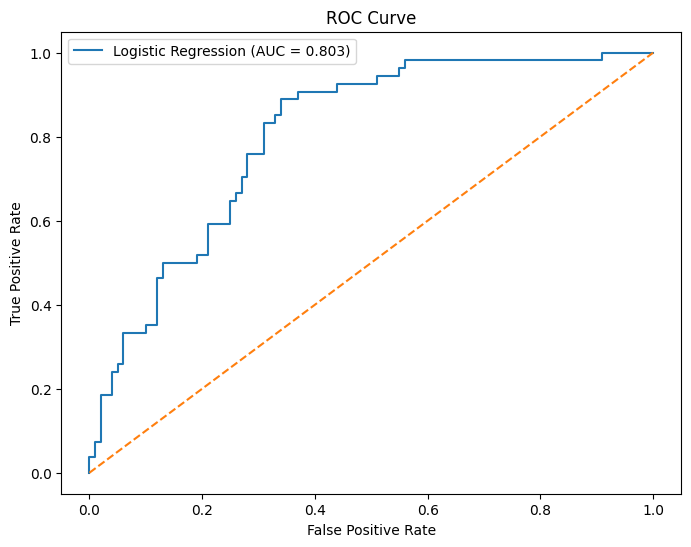

In [46]:
fpr, tpr, thresholds = roc_curve(
    y_test_cls,
    y_prob_cls
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

## Step 27  Compare the Two Models

In [47]:
results = pd.DataFrame({
    "Task": [
        "Regression",
        "Classification"
    ],
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],
    "Primary Metric": [
        f"RMSE = {rmse:.3f}",
        f"F1 = {f1:.3f}"
    ]
})

results

,Task,Model,Primary Metric
0,Regression,Linear Regression,RMSE = 5.898
1,Classification,Logistic Regression,F1 = 0.545


### Regression

In [48]:
regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Score": [
        mae,
        mse,
        rmse,
        r2
    ]
})

regression_results

,Metric,Score
0,MAE,4.386727
1,MSE,34.788373
2,RMSE,5.898167
3,R²,0.204610


### Classification

In [49]:
classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

classification_results

,Metric,Score
0,Accuracy,0.707792
1,Precision,0.600000
2,Recall,0.500000
3,F1 Score,0.545455
4,ROC-AUC,0.802963


## Step 28  Model Interpretation

For the classification model, we can inspect coefficients

In [50]:
classification_coefficients = pd.DataFrame({
    "Feature": classification_features,
    "Coefficient": classification_model.coef_[0]
})

classification_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Glucose,1.174691
3,SkinThickness,0.358816
0,Pregnancies,0.336142
5,DiabetesPedigreeFunction,0.278877
2,BloodPressure,0.110085
6,Age,0.054869
4,Insulin,-0.011915


This lets us see which features have positive or negative associations with the model's diabetes prediction.

### For regression

In [51]:
regression_coefficients = pd.DataFrame({
    "Feature": regression_features,
    "Coefficient": regression_model.coef_
})

regression_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
3,SkinThickness,3.566725
2,BloodPressure,1.315326
1,Glucose,0.888862
5,DiabetesPedigreeFunction,0.547592
4,Insulin,0.349148
0,Pregnancies,-0.022242
6,Age,-1.023438


## Step 29  Final Conclusions

## Conclusion

This project implemented two supervised machine learning problems using the
Pima Indians Diabetes dataset.

For regression, Linear Regression was used to predict BMI from clinical and
demographic variables. The model was evaluated using MAE, MSE, RMSE, and R².

For classification, Logistic Regression was used to predict whether a patient
had diabetes. Accuracy, precision, recall, F1-score, ROC-AUC, and a confusion
matrix were used for evaluation.

The preprocessing stage included identifying physiologically invalid zero
values, treating them as missing values, imputing missing values using the
median, standardizing numerical features, and separating training and testing
data.

The regression results indicate how well the selected clinical variables can
estimate BMI, while the classification results indicate how effectively the
model can distinguish between diabetic and non-diabetic patients.

The project demonstrates the complete machine learning workflow from raw
healthcare data to model evaluation and interpretation.